In [28]:
# importing all the required libraries

import pandas as pd
import seaborn as sns 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_auc_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import average_precision_score
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
import scipy.stats as statsimport shap


# Importing and splitting the data into training and testing

In [29]:
# importing the file with the combined data of both the hospitals and splitting it into 2 parts

combined = pd.read_csv('/kaggle/input/prediction-of-sepsis/Dataset.csv')
#sepsis-physionet

rows_to_drop = combined.loc[combined['Patient_ID'].apply(lambda x: len(str(x)) == 6)]
df_train = combined.drop(rows_to_drop.index)
df_train.to_csv('data_part1.csv', index=False)

rows_to_drop = combined.loc[combined['Patient_ID'].apply(lambda x: len(str(x)) != 6)]
df_test = combined.drop(rows_to_drop.index)
df_test.to_csv('data_part2.csv', index=False)

In [30]:
# importing the test and training data

df_train = pd.read_csv('/kaggle/working/data_part1.csv')
df_test = pd.read_csv('/kaggle/working/data_part2.csv')

# Exploratory data analysis

In [13]:
df_train.head(15)
df_train.columns

Index(['Unnamed: 0', 'Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP',
       'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2',
       'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine',
       'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate',
       'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC',
       'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2',
       'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID', 'Unit'],
      dtype='object')

As can be seen, this is a time series data. The dataframe has 44 columns. After the first loook at data, it can be observed that the data seems quite sparse.

In [70]:
# let's list down all the different columns

df_train.columns



Index(['Unnamed: 0', 'Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP',
       'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2',
       'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine',
       'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate',
       'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC',
       'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2',
       'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID', 'Unit'],
      dtype='object')

In [6]:
# list of all the unique patients
# total number of patients present in the dataset

patients = list(df_test['Patient_ID'].unique())
len(patients)

20000

In [32]:
# Function to draw correlation heat map 

def corr_matrix(df):
  corr = df.corr()
  mask = np.triu(np.ones_like(corr, dtype=bool))
  f, ax = plt.subplots(figsize=(40,40))
  cmap = sns.diverging_palette(220, 10, as_cmap=True)
  sns.heatmap(corr, mask=mask, cmap="Paired", vmax=.3, center=0,
              square=True, linewidths=.5, cbar_kws={"shrink": .5})

In [33]:
# Percentage of null values present in all the parameters 

null_values = df_train.isnull().mean()*100
null_values = null_values.sort_values(ascending=False)
null_values

EtCO2               100.000000
TroponinI            99.877881
Bilirubin_direct     99.850420
Fibrinogen           99.236917
Bilirubin_total      98.773372
Alkalinephos         98.540650
AST                  98.504205
Lactate              96.565112
PTT                  95.152459
SaO2                 95.044387
Calcium              95.024392
Phosphate            94.951247
Platelets            93.482913
Creatinine           93.357884
WBC                  92.489639
Magnesium            92.219712
HCO3                 91.949406
BUN                  91.840702
Chloride             91.676063
PaCO2                91.231753
Hgb                  91.164303
BaseExcess           89.574863
Potassium            89.137640
pH                   88.532868
Hct                  88.223711
Glucose              87.768392
FiO2                 85.807027
Temp                 66.224255
Unit1                48.868346
Unit2                48.868346
DBP                  48.125763
SBP                  15.211177
O2Sat   

In [34]:
combined['Patient_ID'].astype(str).str.len().value_counts()

6    761995
5    401789
4    349653
3     35107
2      3104
1       562
Name: Patient_ID, dtype: int64


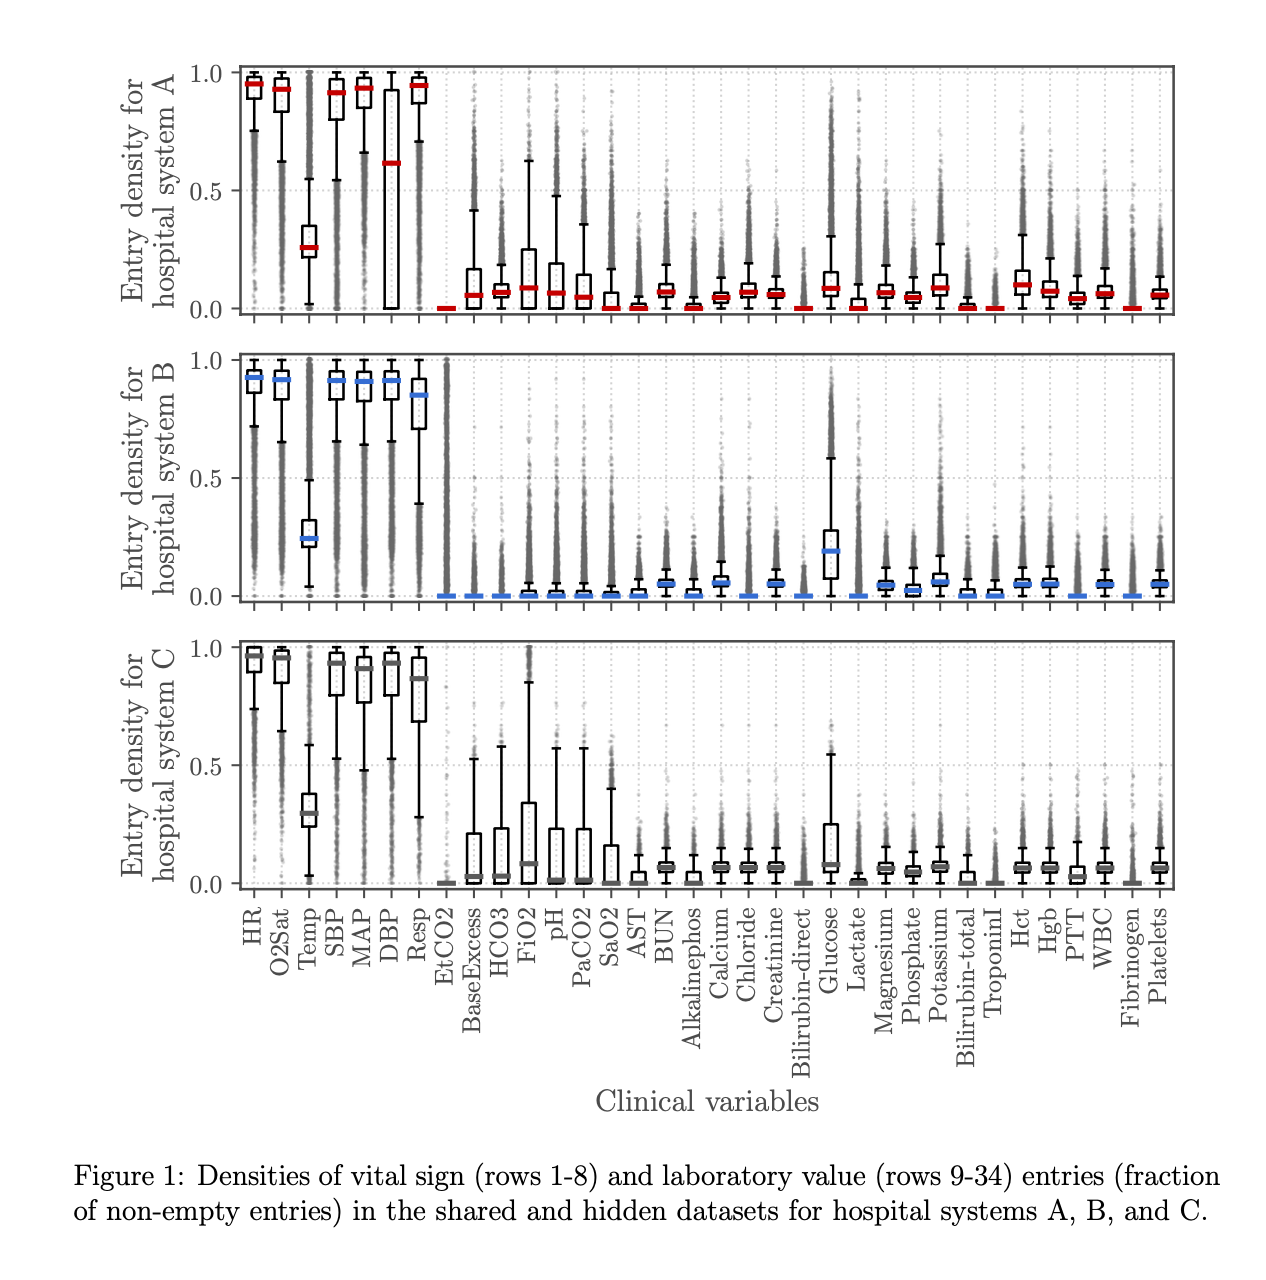

Image obtained from the official pdf of the PhysioNet Challenge. The image gives an overall idea of the number of records available for each feature, for all the three datasets of three different hospitals.

After thorough analysis of the data, it was found that a lot of the features were redundant, i.e. a lot of the features were indicative of the same parameter, so those features were removed on the basis of their sparsity. Another criteria taken into consideration was ease of getting the parameter among different hospitals, becuase some of the parameters are easier to obtain for a given hospital while some are expensive and for some a hospital does not even have infrastructure to get those features.

In [35]:
# the features have been removed based on the number of null values and redundancy 

# 'Unnamed: 0'-- this is the index column
# 'SBP' -- MAP is considered instead of SBP and DBP
# 'DBP' -- MAP is considered instead of SBP and DBP
# 'EtCO2' -- It is not readily. available and also not available in the dataset
# 'BaseExcess' -- It is an indicator of the health of kidney and pancreas but is redundant here becuase a lot of different features for kidney are being considered here. 
# 'HCO3' -- It is also an indicator of the health of kidney and pancreas but is redundant here becuase a lot of different features for kidney are being considered here.
# 'pH' -- It is also an indicator of the health of kidney and pancreas but is redundant here becuase a lot of different features for kidney are being considered here.
# 'PaCO2' -- It is an indicator of respiratory health of an individual, we are considering SaO2 and FiO2 which are more readily avaiilable
# 'Alkalinephos' -- It is an indicator of the health of the liver of an individual, but we are considering Bilirubin instead of this, as data of this is more scarce.
# 'Calcium' -- It is also an indicator of the health of kidney but is redundant here becuase a lot of different features for kidney are being considered here.
# 'Magnesium' -- It is an indicator of metabolism and kidney health, but we are considering Lactate instead as it is more readily available
# 'Phosphate' -- It is also an indicator of the health of kidney but is redundant here becuase a lot of different features for kidney are being considered here.
# 'Potassium' -- It is also an indicator of the health of kidney but is redundant here becuase a lot of different features for kidney are being considered here.
# 'PTT' -- It is used to check inflammation. We are using WBC counts instead as it is easy to obtain.
# 'Fibrinogen' -- It is used to check blood clotting ability. We are using Platelets instead, as it is easier to obtain.
# 'Unit1' -- Both the columns Unit1 and Unit2 have been merged to form a single column.
# 'Unit2' -- Both the columns Unit1 and Unit2 have been merged to form a single column.

columns_drop={'Unnamed: 0','SBP','DBP','EtCO2','BaseExcess', 'HCO3','pH','PaCO2','Alkalinephos', 'Calcium','Magnesium', 
'Phosphate','Potassium','PTT','Fibrinogen','Unit1','Unit2'}
df_train = df_train.assign(Unit=df_train['Unit1'] + df_train['Unit2'])
df_train_mod = df_train.drop(columns=columns_drop)
df_train_mod.columns

Index(['Hour', 'HR', 'O2Sat', 'Temp', 'MAP', 'Resp', 'FiO2', 'SaO2', 'AST',
       'BUN', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose',
       'Lactate', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'WBC',
       'Platelets', 'Age', 'Gender', 'HospAdmTime', 'ICULOS', 'SepsisLabel',
       'Patient_ID', 'Unit'],
      dtype='object')

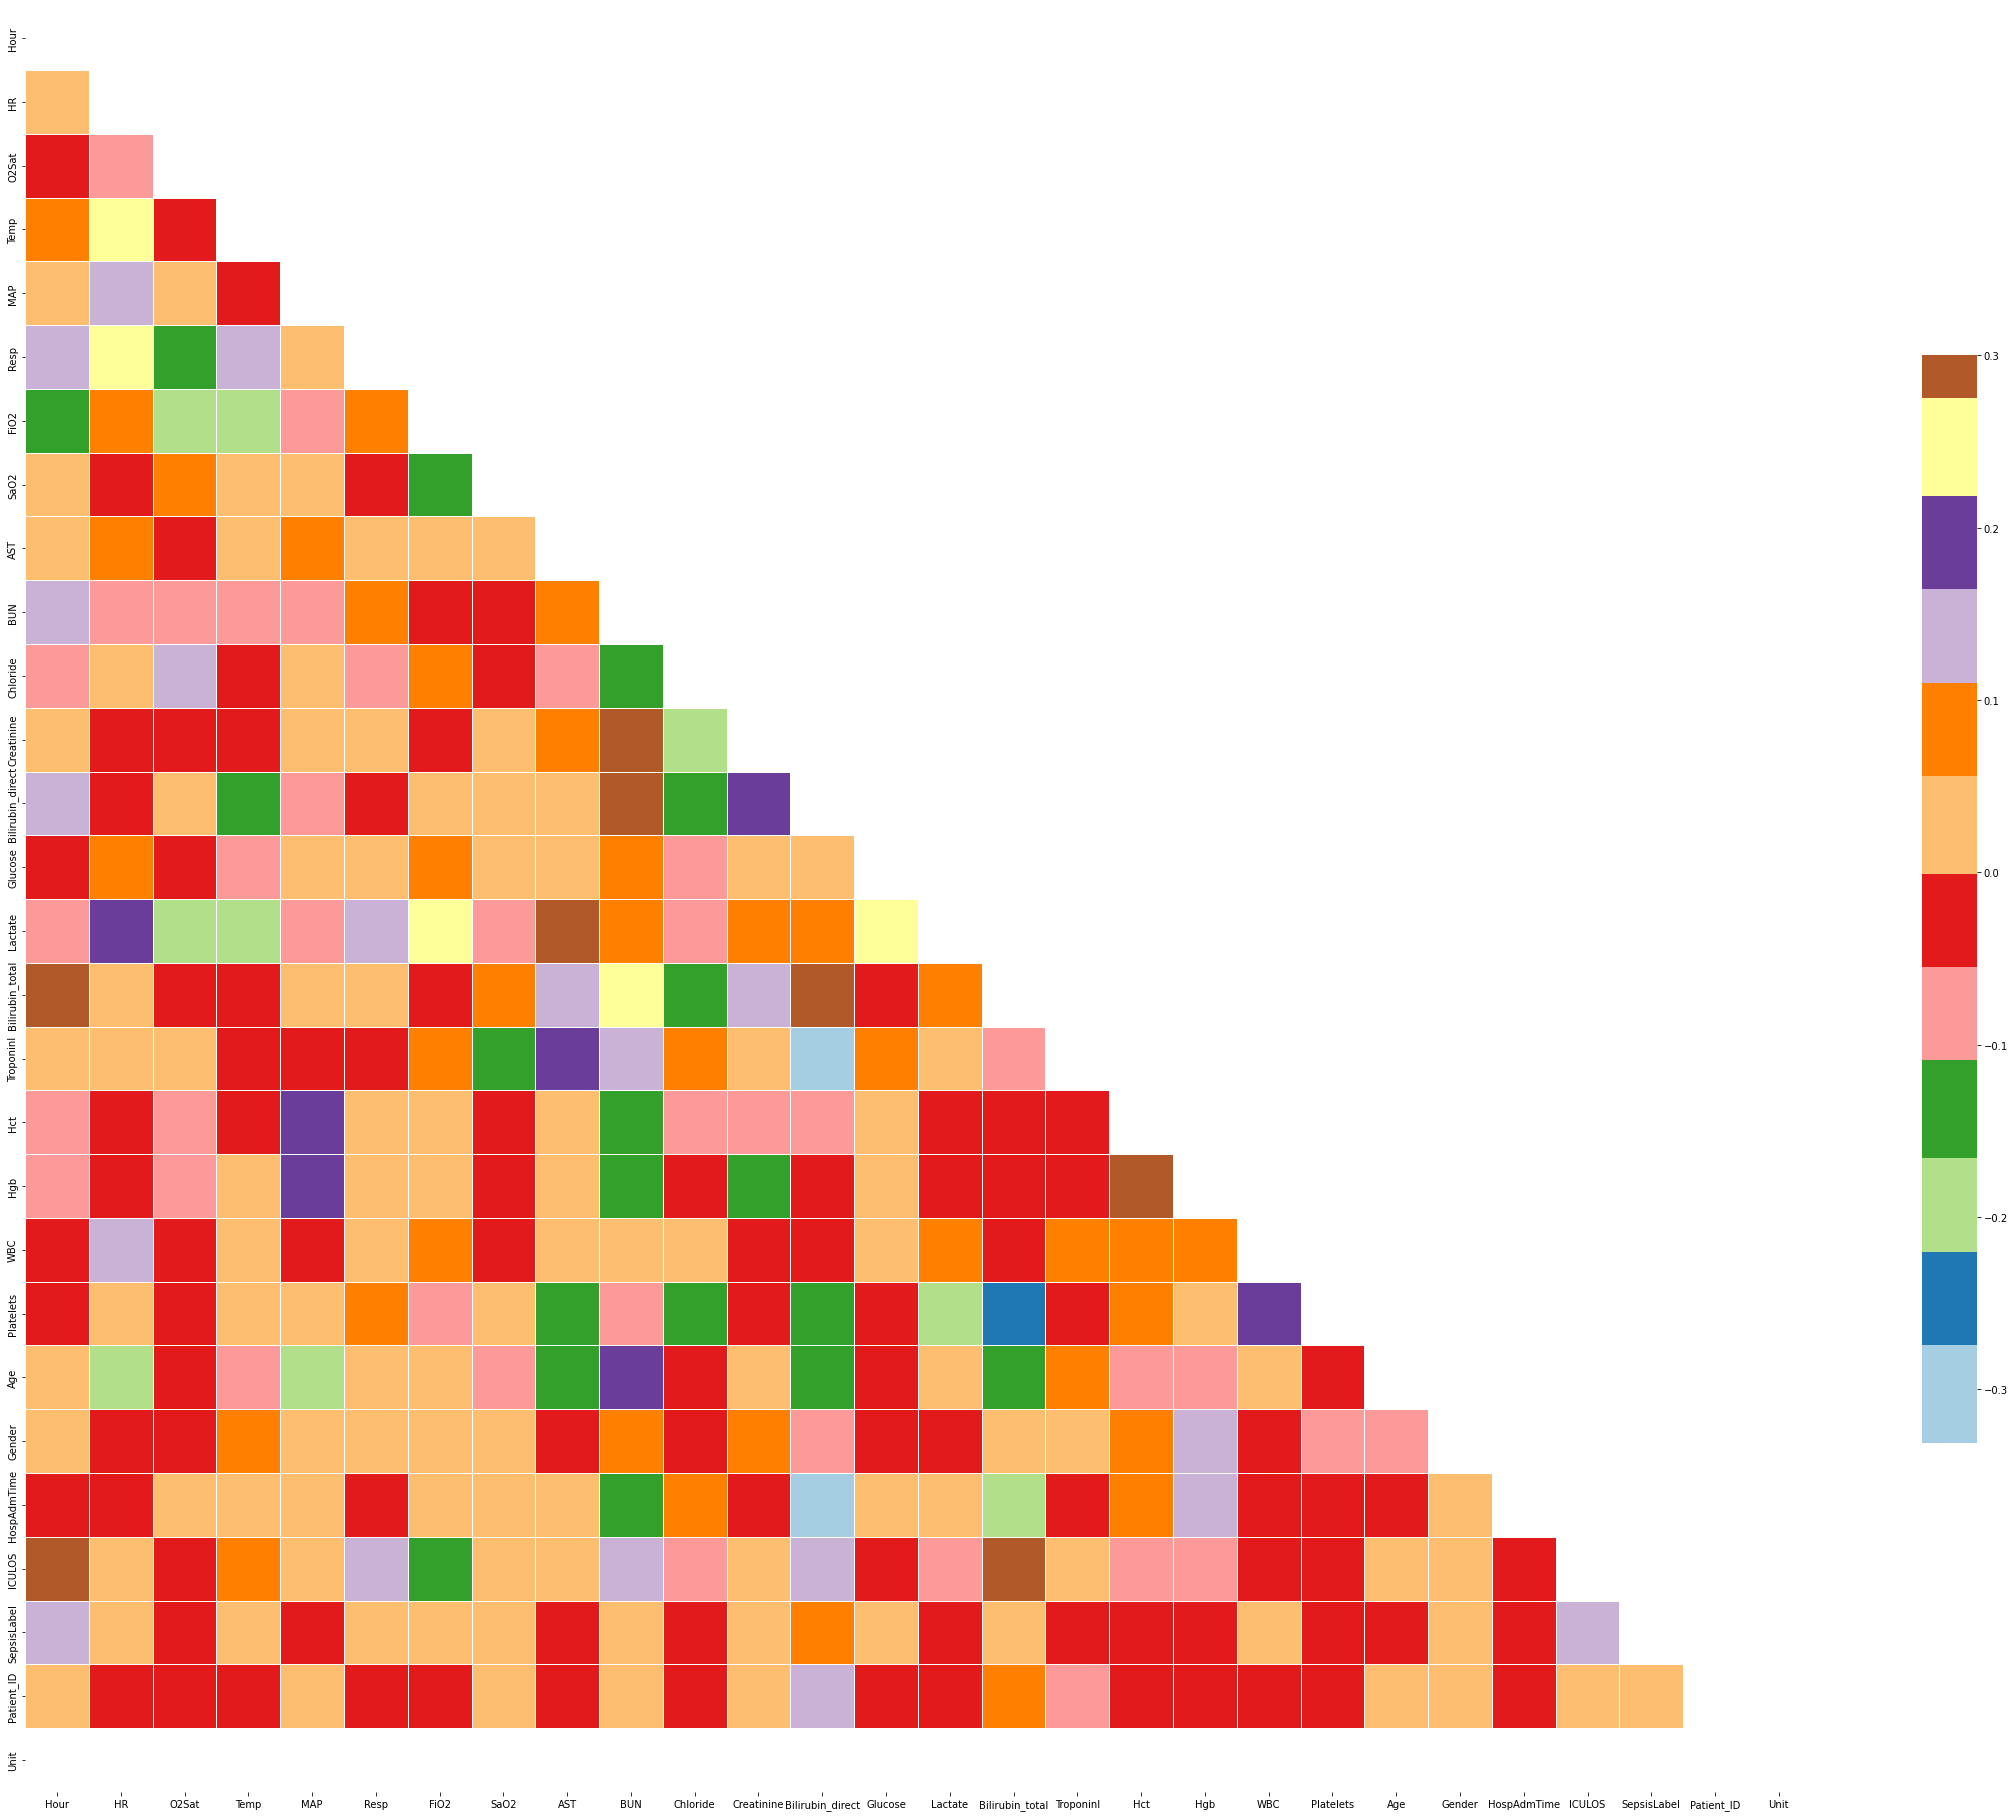

In [36]:
# correlation matrix to check if there is high correlation between the remaining features

corr_matrix(df_train_mod)

As can be seen in this correlation heat map almost all of the feature do not have high correlation.

# Imputation

Since there are a lot of missing values in the dataset, therefore imputation was done to fill the missing values. While imputing, it is important to note that ***imputation should be done on per patient basis,*** otherwise the data from one patient will leak into the data of the other patient. Also another point that should be taken into consideration is that mean, median, mode can not directly be used to impute as it will result in uneven distribution of the parameters with respect to time.

In [38]:
df_train_impute = df_train_mod.copy()
columns_impute = list(df_train_impute.columns)

In [39]:
# bfill and ffill for imputing

grouped_by_patient = df_train_impute.groupby('Patient_ID')
df_train_impute = grouped_by_patient.apply(lambda x: x.bfill().ffill())

# Temporal Feature Engineering

Since ICU data is inherently temporal, we engineer features that capture how a patient's vitals change over time. For each of the 5 key vital signs (HR, O2Sat, Temp, MAP, Resp), we compute:
- **Delta**: hour-to-hour change (captures acute changes)
- **6-hour rolling mean**: smoothed trend (captures sustained deterioration)

We also add two clinical composite features:
- **Shock Index** (HR / MAP): a known early indicator of hemodynamic instability
- **BUN/Creatinine ratio**: a marker of renal function deterioration

In [ ]:
# Temporal feature engineering — computed per patient after imputation
df_train_impute = df_train_impute.sort_values(['Patient_ID', 'ICULOS'])
g_temporal = df_train_impute.groupby('Patient_ID')

# Delta (hour-to-hour change) and 6h rolling mean for vital signs
for feat in ['HR', 'O2Sat', 'Temp', 'MAP', 'Resp']:
    df_train_impute[f'{feat}_delta'] = g_temporal[feat].diff().fillna(0)
    df_train_impute[f'{feat}_rmean_6h'] = g_temporal[feat].transform(
        lambda x: x.rolling(6, min_periods=1).mean()
    )

# Clinical composite features
df_train_impute['shock_index'] = df_train_impute['HR'] / (df_train_impute['MAP'] + 1e-6)
df_train_impute['bun_creatinine_ratio'] = df_train_impute['BUN'] / (df_train_impute['Creatinine'] + 1e-6)

print(f"Added 12 temporal features. New shape: {df_train_impute.shape}")

In [16]:
df_train_impute.head()

,Hour,HR,O2Sat,Temp,MAP,Resp,FiO2,SaO2,AST,BUN,...,Hgb,WBC,Platelets,Age,Gender,HospAdmTime,ICULOS,SepsisLabel,Patient_ID,Unit
0,0,65.0,100.0,35.78,72.0,16.5,0.4,NaN,29.0,23.0,...,9.5,11.3,330.0,68.54,0,-0.02,1,0,17072,NaN
1,1,65.0,100.0,35.78,72.0,16.5,0.4,NaN,29.0,23.0,...,9.5,11.3,330.0,68.54,0,-0.02,2,0,17072,NaN
2,2,78.0,100.0,35.78,42.5,17.0,0.4,NaN,29.0,23.0,...,9.5,11.3,330.0,68.54,0,-0.02,3,0,17072,NaN
3,3,73.0,100.0,35.78,74.0,17.0,0.4,NaN,29.0,23.0,...,9.5,11.3,330.0,68.54,0,-0.02,4,0,17072,NaN
4,4,70.0,100.0,35.78,74.0,14.0,0.4,NaN,29.0,23.0,...,9.5,11.3,330.0,68.54,0,-0.02,5,0,17072,NaN


In [40]:
# Now let's check the remaining proportion of missing values
### entiure columns are null

null_values = df_train_impute.isnull().mean()*100
null_values = null_values.sort_values(ascending=False)
null_values

TroponinI           97.357934
Bilirubin_direct    96.256841
Bilirubin_total     66.949754
AST                 66.435590
SaO2                57.282891
Lactate             55.997418
Unit                48.868346
FiO2                36.195592
WBC                  1.511994
Platelets            1.394810
Chloride             1.310656
Hgb                  1.158672
Creatinine           1.029467
Glucose              0.940630
BUN                  0.937719
Temp                 0.853692
Hct                  0.779028
Resp                 0.088710
O2Sat                0.026702
MAP                  0.003037
HR                   0.001139
HospAdmTime          0.001012
Age                  0.000000
Gender               0.000000
ICULOS               0.000000
SepsisLabel          0.000000
Patient_ID           0.000000
Hour                 0.000000
dtype: float64

'TroponinI', 'Bilirubin_direct', 'AST', 'Bilirubin_total', 'Lactate', 'SaO2', 'FiO2', 'Unit', 'Patient_ID'  have more than 25 percent of null values and hence are dropped from the dataset. 

In [41]:
# dropping all the columns with null values more than 25% and patient_id
# IMPORTANT: Save Patient_ID before dropping — needed for patient-level split

patient_ids = df_train_impute['Patient_ID'].copy()

null_col = ['TroponinI', 'Bilirubin_direct', 'AST', 'Bilirubin_total', 'Lactate', 'SaO2', 'FiO2',
            'Unit', 'Patient_ID']
df_train_impute = df_train_impute.drop(columns=null_col)
df_train_impute.columns

Index(['Hour', 'HR', 'O2Sat', 'Temp', 'MAP', 'Resp', 'BUN', 'Chloride',
       'Creatinine', 'Glucose', 'Hct', 'Hgb', 'WBC', 'Platelets', 'Age',
       'Gender', 'HospAdmTime', 'ICULOS', 'SepsisLabel'],
      dtype='object')

In [43]:
# onehot encoding the gender

one_hot = pd.get_dummies(df_train_impute['Gender'])
df_train_impute = df_train_impute.join(one_hot)
df_train_impute = df_train_impute.drop('Gender', axis=1)


KeyError: 'Gender'

## Gaussian Transformation and Standard Normalization

Generally models tend to give a better result for a normal ditribution. So in the below cells we explored different techniques to plot histograms and QQ plots of all the features and then we applied different transformations on it to see which were giving good results. The ones giving the beest results were then adopted in the dataframe.

In [44]:
# function to draw histogram and QQ plot 

def diagnostic_plots(df, variable):
    fig = plt.figure(figsize=(15,4))
    ax = fig.add_subplot(121)
    df[variable].hist(bins=30)
    ax = fig.add_subplot(122)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.xlabel(variable)
    plt.show()

In [46]:
# function to apply different transformations to make the plot gaussian

def try_gaussian(df, col):
  print('actual plot')
  diagnostic_plots(df,col)
  # this applies yeojohnson plot
  df['col_yj'], param = stats.yeojohnson(df[col]) 
  print('yeojohnson plot')
  diagnostic_plots(df, 'col_yj')
  # this applies exponential transformation
  df['col_1.5'] = df[col]**(1/1.5)
  print('**1/1.5 plot') 
  diagnostic_plots(df, 'col_1.5')
  df['col_.5'] = df[col]**(.5)
  print('**.5 plot') 
  # this applies inverse transformation
  diagnostic_plots(df, 'col_.5')
  df['col_rec'] = 1 / (df[col]+0.00001) 
  diagnostic_plots(df, 'col_rec')
  # this applies logarithmic trasnformation
  df['col_log'] = np.log(df[col]+1)
  diagnostic_plots(df, 'col_log')    


O2Sat
actual plot


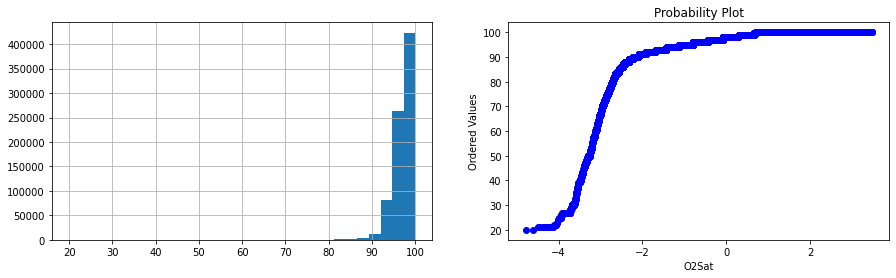

yeojohnson plot


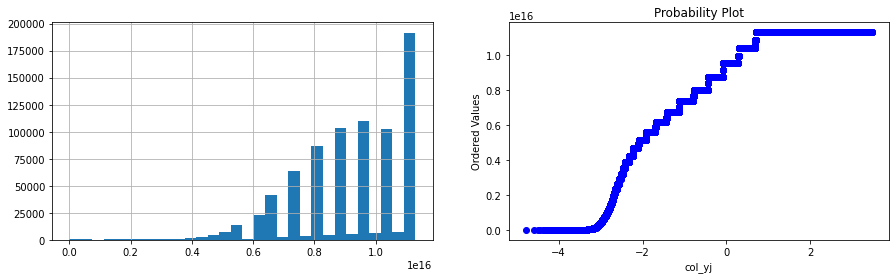

**1/1.5 plot


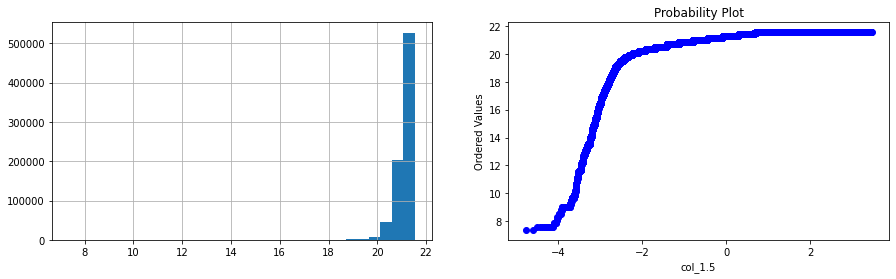

**.5 plot


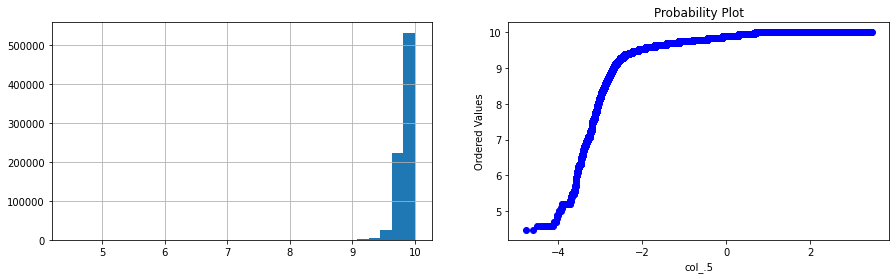

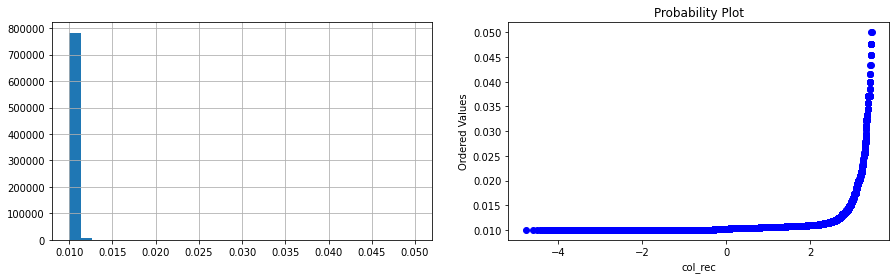

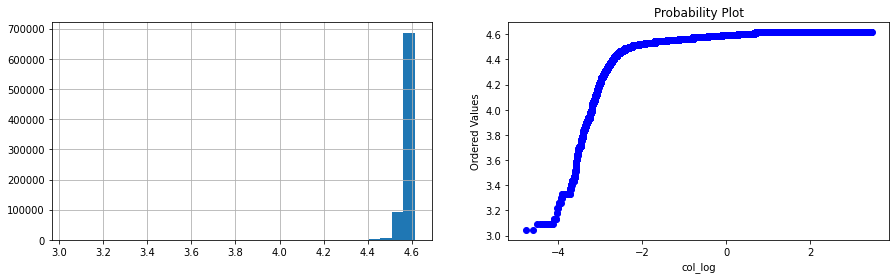

Temp
actual plot


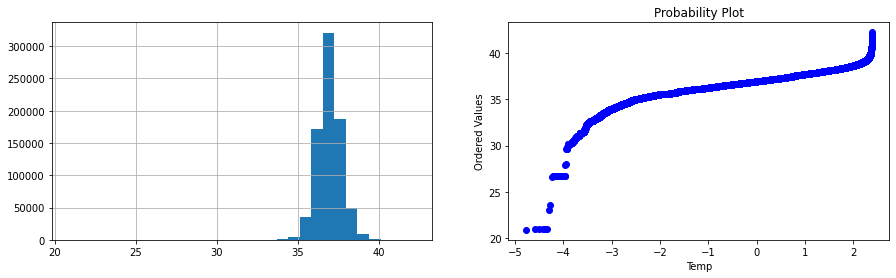

yeojohnson plot


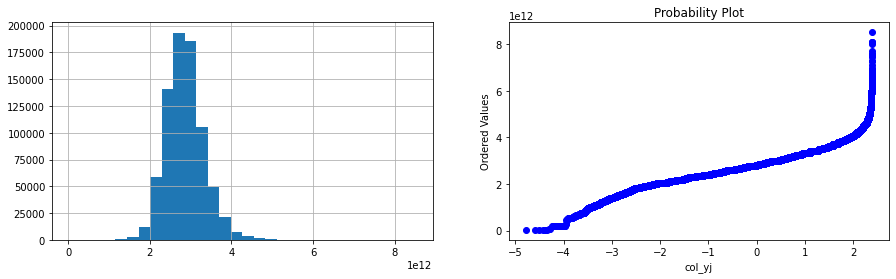

**1/1.5 plot


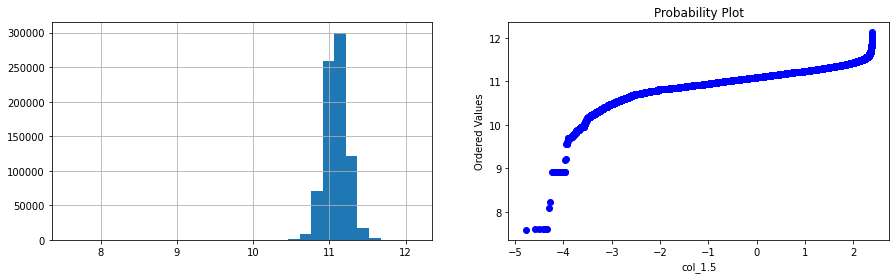

**.5 plot


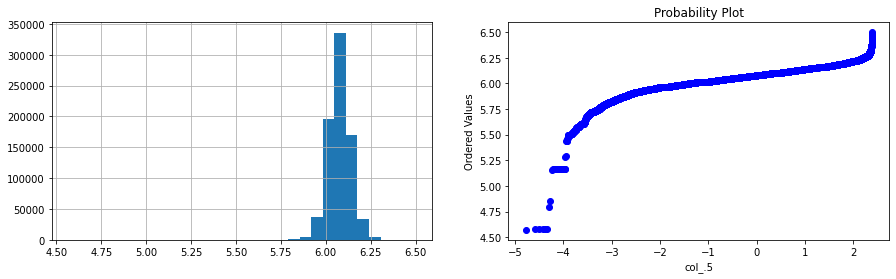

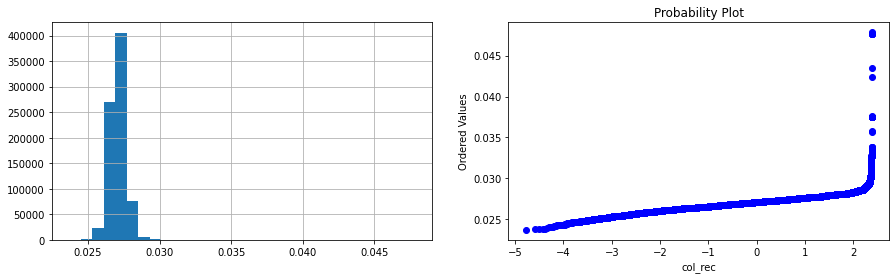

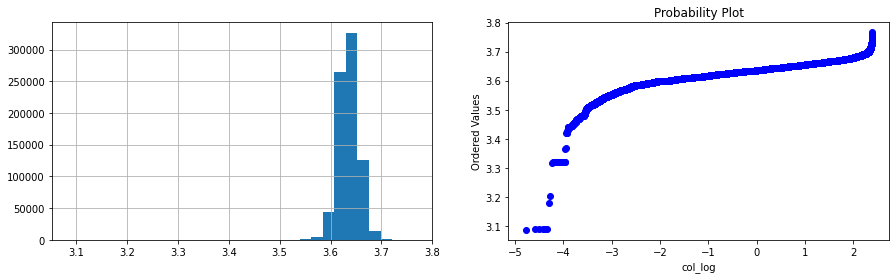

MAP
actual plot


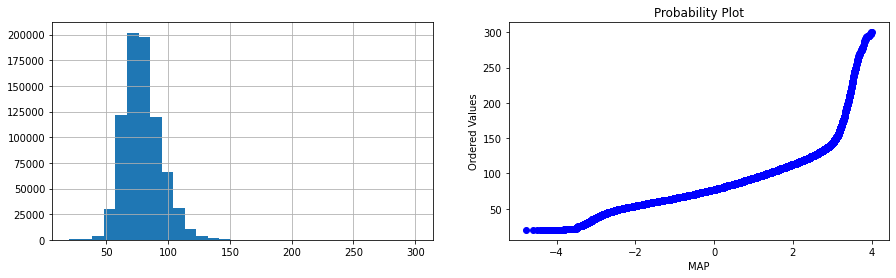

yeojohnson plot


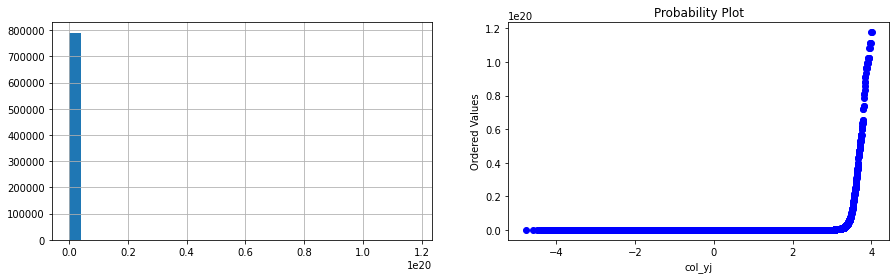

**1/1.5 plot


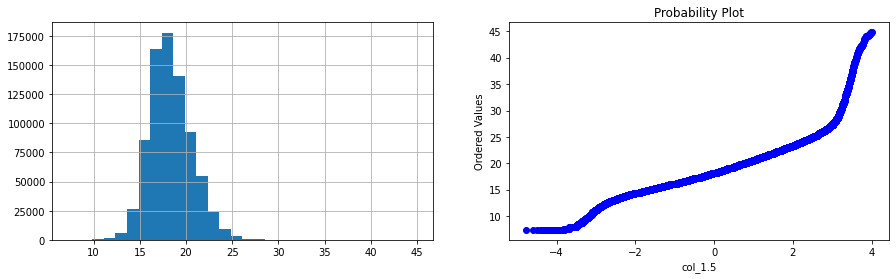

**.5 plot


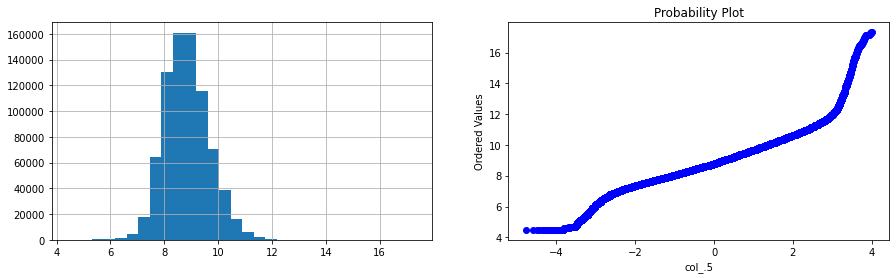

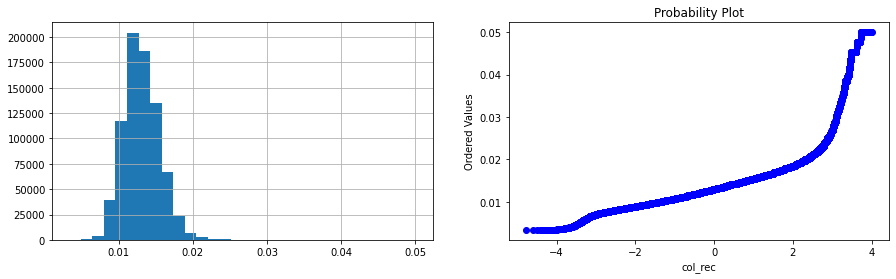

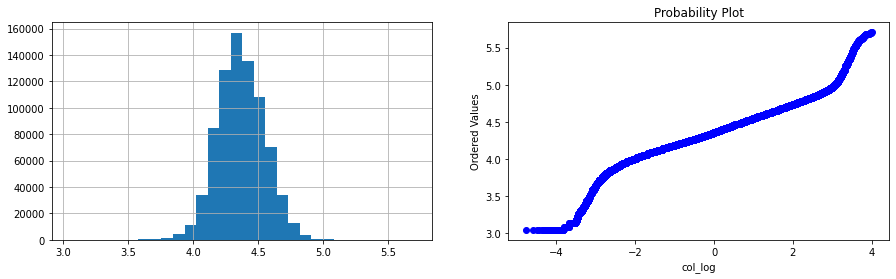

BUN
actual plot


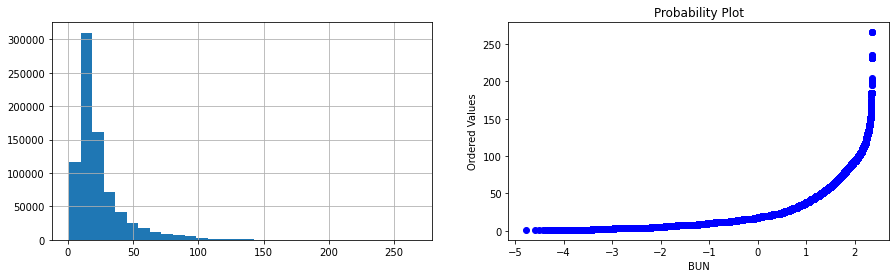

yeojohnson plot


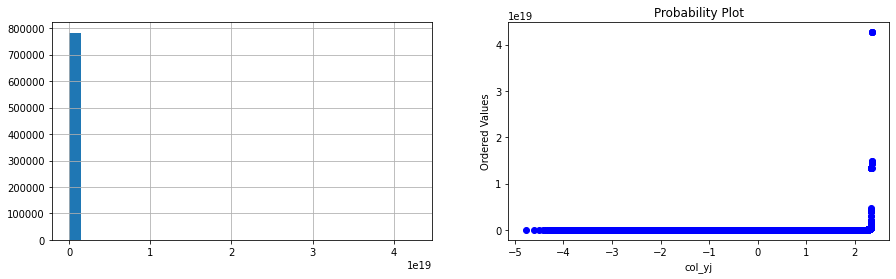

**1/1.5 plot


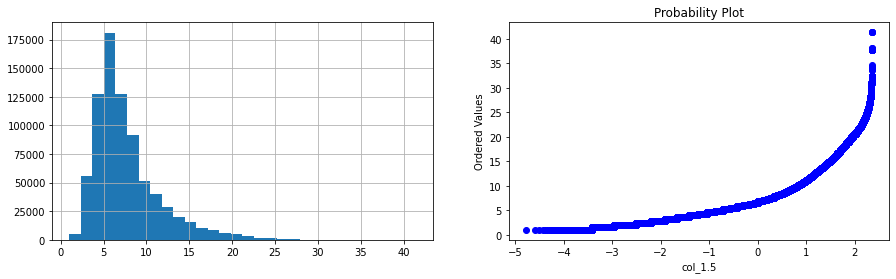

**.5 plot


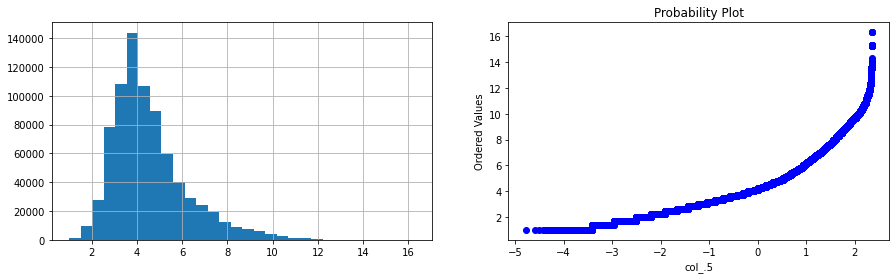

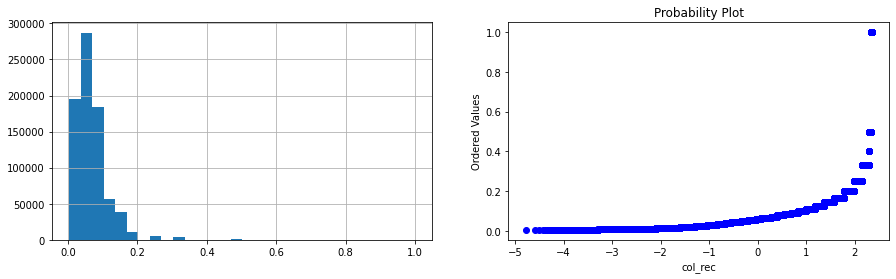

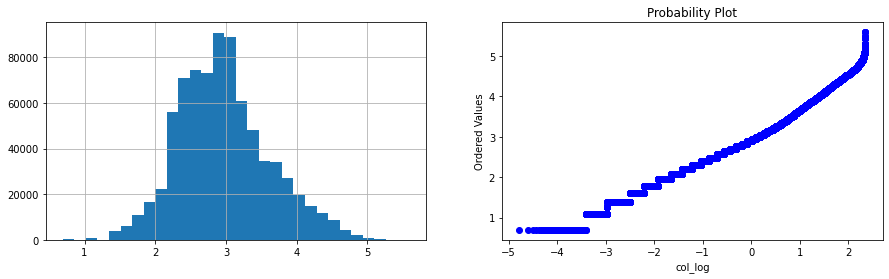

Creatinine
actual plot


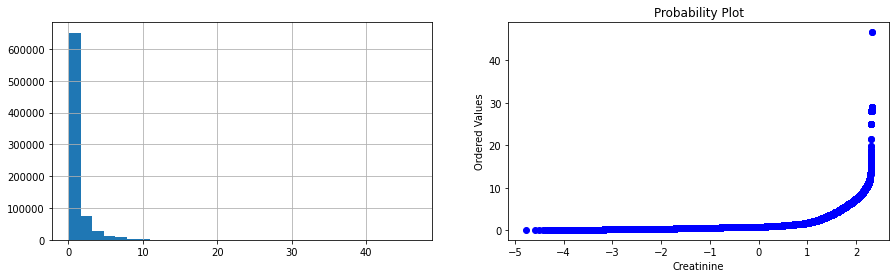

yeojohnson plot


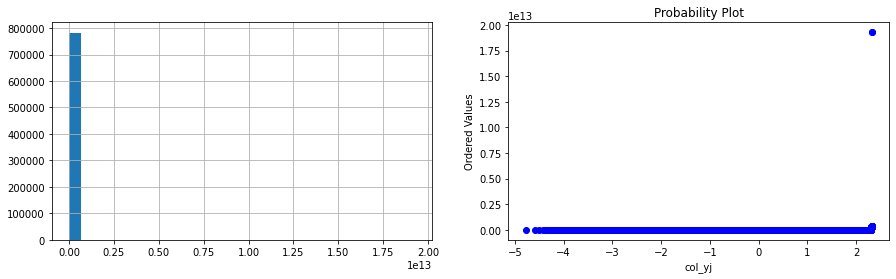

**1/1.5 plot


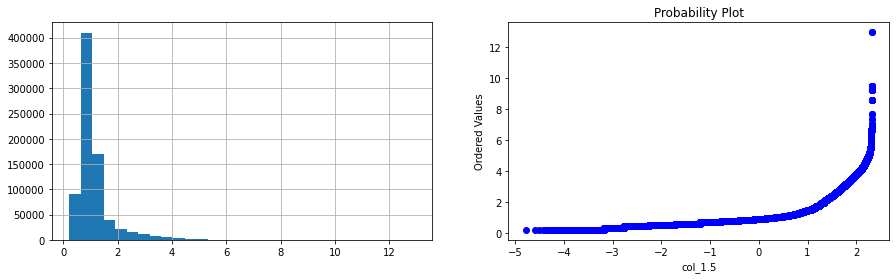

**.5 plot


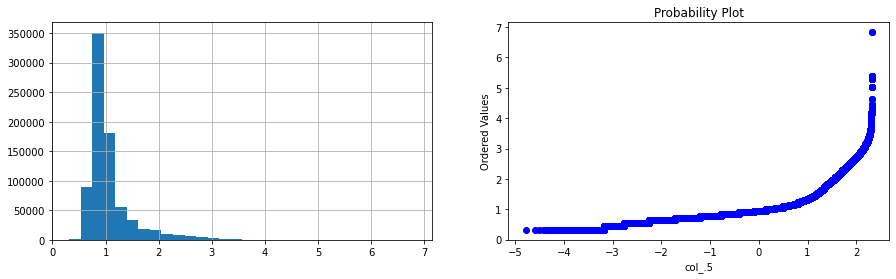

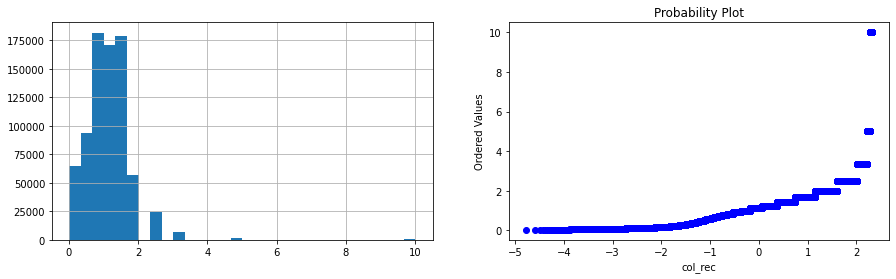

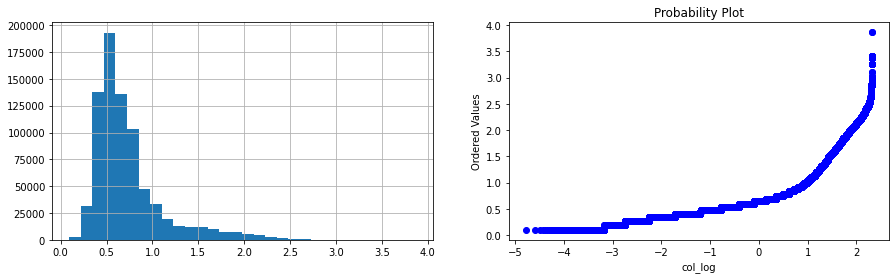

Glucose
actual plot


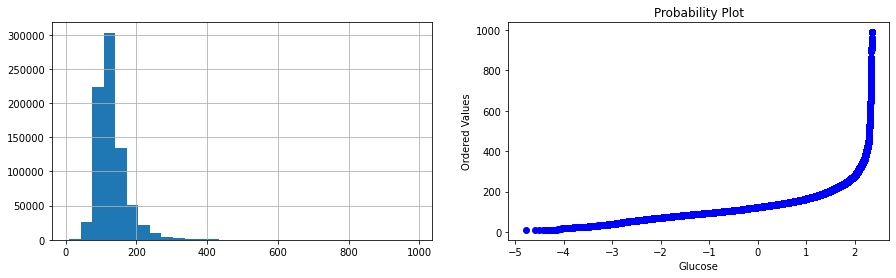

yeojohnson plot


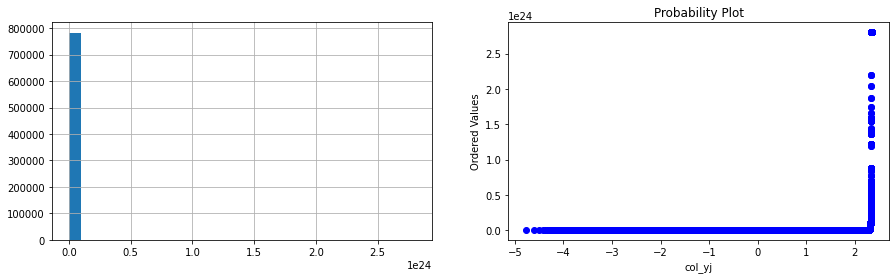

**1/1.5 plot


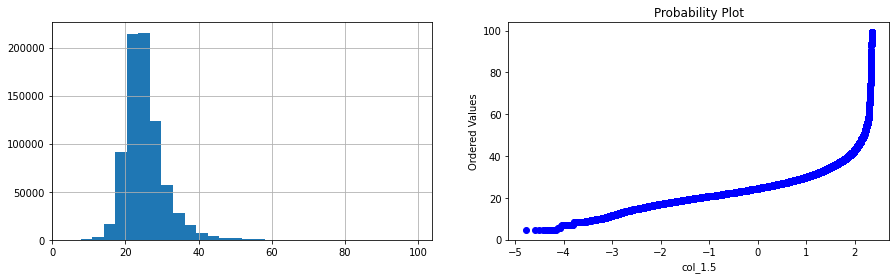

**.5 plot


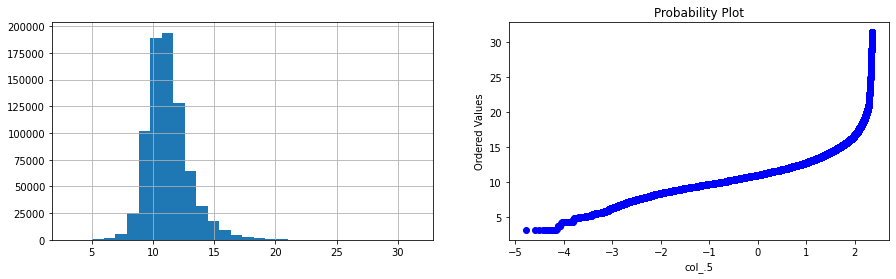

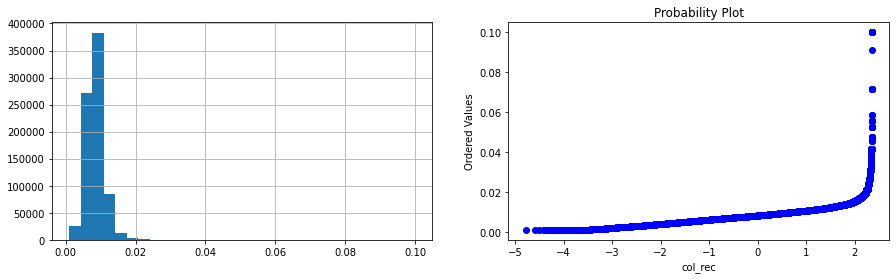

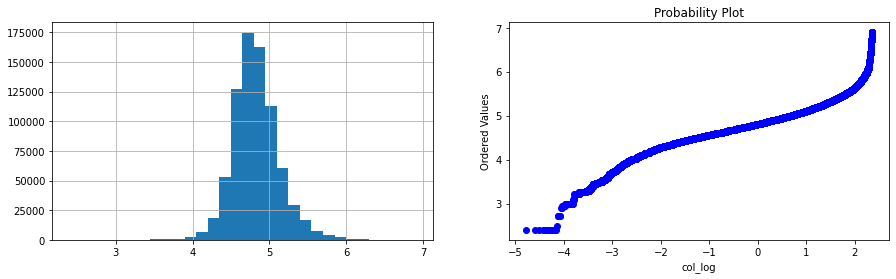

WBC
actual plot


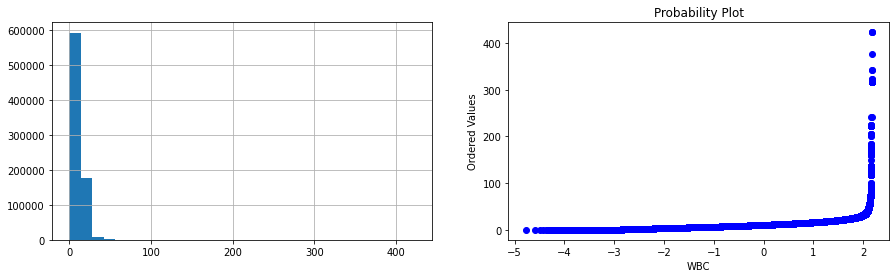

yeojohnson plot


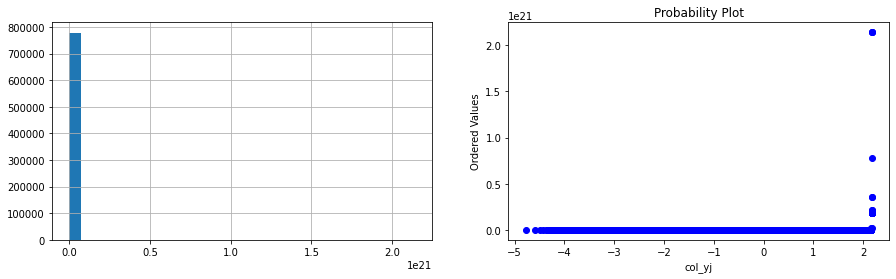

**1/1.5 plot


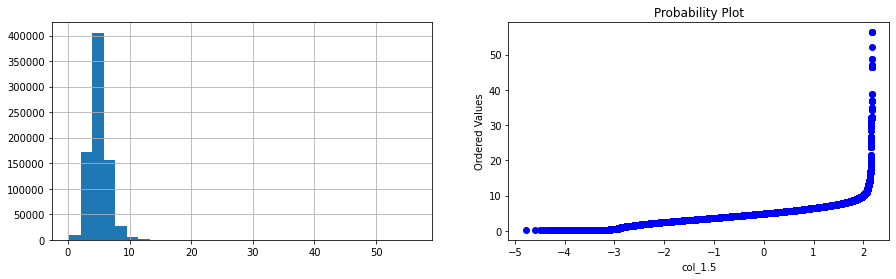

**.5 plot


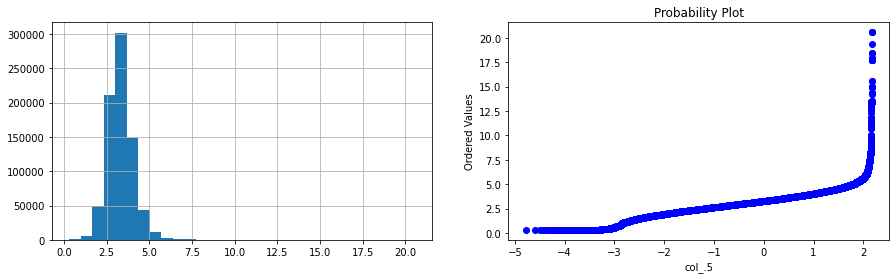

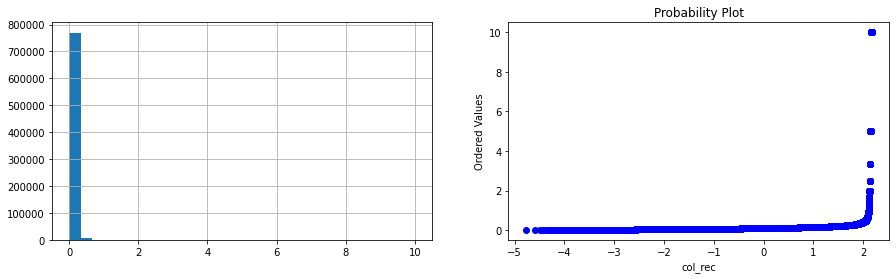

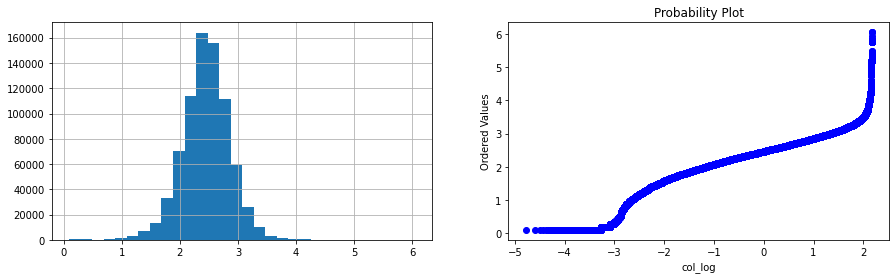

Platelets
actual plot


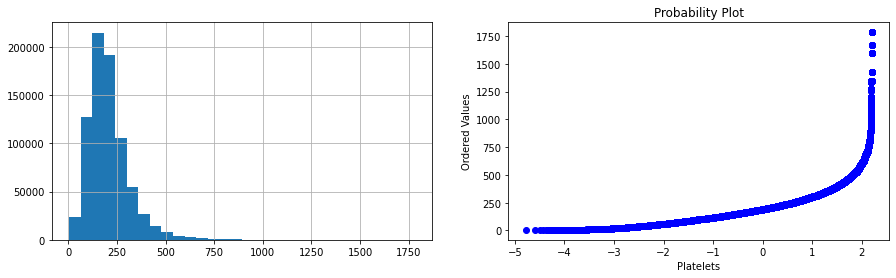

yeojohnson plot


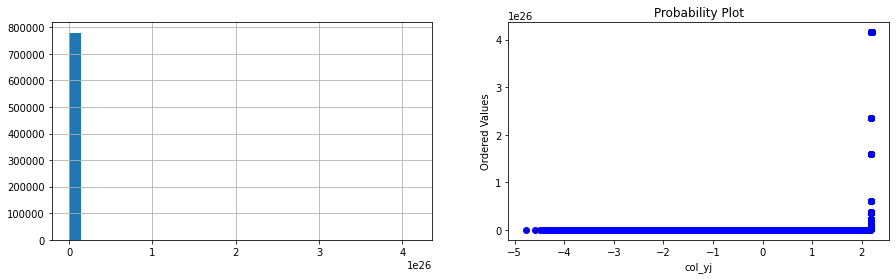

**1/1.5 plot


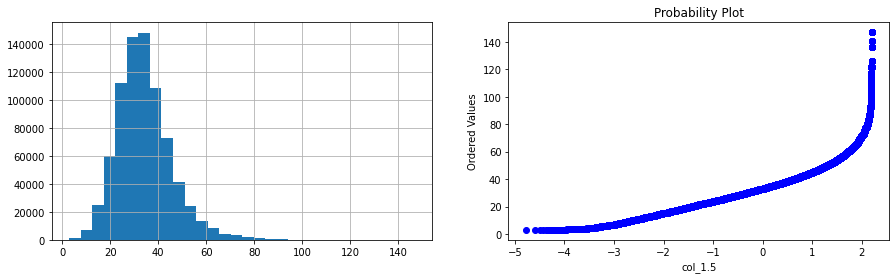

**.5 plot


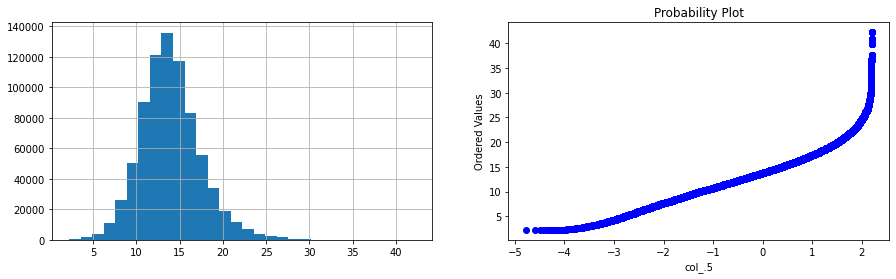

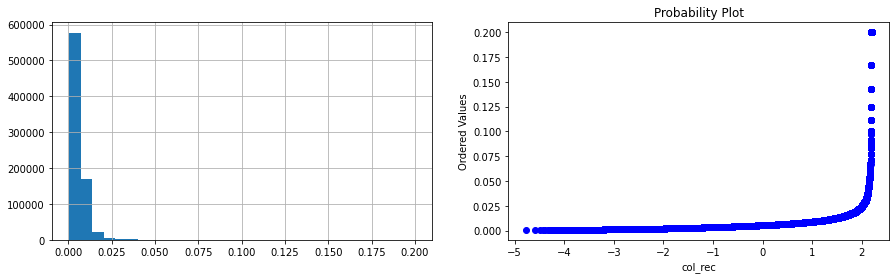

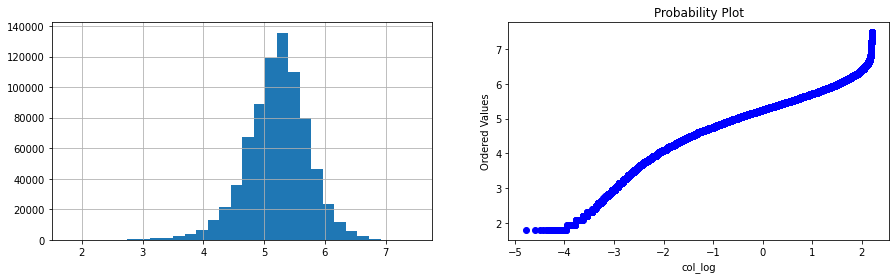

In [47]:
# try normal distribution
# Now we try to check the distribution of values present in different columns after application of various transformations

lst = ['O2Sat', 'Temp', 'MAP', 'BUN', 'Creatinine', 'Glucose', 'WBC', 'Platelets' ]
for i in lst:
  print(i)
  try_gaussian(df_train_impute, i)

In [48]:
# after application of the above code, some redundant columns got added to the dataframe, which are removed through this line of code

df_train_impute = df_train_impute.drop(columns = ['col_yj','col_1.5','col_.5','col_rec','col_log'])

In [49]:
df_train_impute.head()

,Hour,HR,O2Sat,Temp,MAP,Resp,BUN,Chloride,Creatinine,Glucose,Hct,Hgb,WBC,Platelets,Age,HospAdmTime,ICULOS,SepsisLabel,0,1
0,0,65.0,100.0,35.78,72.0,16.5,23.0,104.0,0.8,161.0,29.7,9.5,11.3,330.0,68.54,-0.02,1,0,1,0
1,1,65.0,100.0,35.78,72.0,16.5,23.0,104.0,0.8,161.0,29.7,9.5,11.3,330.0,68.54,-0.02,2,0,1,0
2,2,78.0,100.0,35.78,42.5,17.0,23.0,104.0,0.8,161.0,29.7,9.5,11.3,330.0,68.54,-0.02,3,0,1,0
3,3,73.0,100.0,35.78,74.0,17.0,23.0,104.0,0.8,161.0,29.7,9.5,11.3,330.0,68.54,-0.02,4,0,1,0
4,4,70.0,100.0,35.78,74.0,14.0,23.0,104.0,0.8,161.0,29.7,9.5,11.3,330.0,68.54,-0.02,5,0,1,0


In [50]:
# by oserving different plots, it can be concluded that only log was somewhat effective and that too for MAP, BUN, Creatinine, Glucose, WBC & Plateletes
# therefore applying log transformations on the above columns

columns_normalized = ['MAP', 'BUN', 'Creatinine', 'Glucose', 'WBC', 'Platelets' ]
for i in columns_normalized:
  df_train_impute[i] = np.log(df_train_impute[i]+1)

In [51]:
df_train_impute.head()

,Hour,HR,O2Sat,Temp,MAP,Resp,BUN,Chloride,Creatinine,Glucose,Hct,Hgb,WBC,Platelets,Age,HospAdmTime,ICULOS,SepsisLabel,0,1
0,0,65.0,100.0,35.78,4.290459,16.5,3.178054,104.0,0.587787,5.087596,29.7,9.5,2.509599,5.802118,68.54,-0.02,1,0,1,0
1,1,65.0,100.0,35.78,4.290459,16.5,3.178054,104.0,0.587787,5.087596,29.7,9.5,2.509599,5.802118,68.54,-0.02,2,0,1,0
2,2,78.0,100.0,35.78,3.772761,17.0,3.178054,104.0,0.587787,5.087596,29.7,9.5,2.509599,5.802118,68.54,-0.02,3,0,1,0
3,3,73.0,100.0,35.78,4.317488,17.0,3.178054,104.0,0.587787,5.087596,29.7,9.5,2.509599,5.802118,68.54,-0.02,4,0,1,0
4,4,70.0,100.0,35.78,4.317488,14.0,3.178054,104.0,0.587787,5.087596,29.7,9.5,2.509599,5.802118,68.54,-0.02,5,0,1,0


In [52]:
# standard normalization — scale both original features and temporal features

scaler = StandardScaler()
original_scale = ['HR', 'O2Sat', 'Temp', 'MAP', 'Resp', 'BUN', 'Chloride',
       'Creatinine', 'Glucose', 'Hct', 'Hgb', 'WBC', 'Platelets']
temporal_cols = [c for c in df_train_impute.columns 
                 if any(s in c for s in ['_delta', '_rmean_', 'shock_index', 'bun_creatinine'])]
all_scale_cols = original_scale + temporal_cols
all_scale_cols = [c for c in all_scale_cols if c in df_train_impute.columns]

df_train_impute[all_scale_cols] = scaler.fit_transform(df_train_impute[all_scale_cols])
df_train_impute.head()

,Hour,HR,O2Sat,Temp,MAP,Resp,BUN,Chloride,Creatinine,Glucose,Hct,Hgb,WBC,Platelets,Age,HospAdmTime,ICULOS,SepsisLabel,0,1
0,0,-1.170030,0.865243,-1.548869,-0.397650,-0.419685,0.322965,-0.226541,-0.410796,0.854631,-0.311111,-0.652538,0.149678,1.140763,68.54,-0.02,1,0,1,0
1,1,-1.170030,0.865243,-1.548869,-0.397650,-0.419685,0.322965,-0.226541,-0.410796,0.854631,-0.311111,-0.652538,0.149678,1.140763,68.54,-0.02,2,0,1,0
2,2,-0.407913,0.865243,-1.548869,-3.187955,-0.326969,0.322965,-0.226541,-0.410796,0.854631,-0.311111,-0.652538,0.149678,1.140763,68.54,-0.02,3,0,1,0
3,3,-0.701035,0.865243,-1.548869,-0.251970,-0.326969,0.322965,-0.226541,-0.410796,0.854631,-0.311111,-0.652538,0.149678,1.140763,68.54,-0.02,4,0,1,0
4,4,-0.876908,0.865243,-1.548869,-0.251970,-0.883265,0.322965,-0.226541,-0.410796,0.854631,-0.311111,-0.652538,0.149678,1.140763,68.54,-0.02,5,0,1,0


In [53]:
# Drop remaining NaN rows and align patient_ids
df_train_impute['_Patient_ID'] = patient_ids.values
df_train_impute = df_train_impute.dropna()

# Extract and remove the saved Patient_ID
patient_ids_clean = df_train_impute['_Patient_ID'].copy()
df_train_impute = df_train_impute.drop(columns=['_Patient_ID'])
print(f"Clean dataset: {df_train_impute.shape}")
print(f"Unique patients preserved: {patient_ids_clean.nunique()}")

In [54]:
null_values = df_train_impute.isnull().mean()*100
null_values

Hour           0.0
HR             0.0
O2Sat          0.0
Temp           0.0
MAP            0.0
Resp           0.0
BUN            0.0
Chloride       0.0
Creatinine     0.0
Glucose        0.0
Hct            0.0
Hgb            0.0
WBC            0.0
Platelets      0.0
Age            0.0
HospAdmTime    0.0
ICULOS         0.0
SepsisLabel    0.0
0              0.0
1              0.0
dtype: float64

# Model Building

In [55]:
# This function transforms Hospital B data through the same pipeline
# including temporal features for prediction

def get_data_ready(df):
  columns_drop={'Unnamed: 0','SBP','DBP','EtCO2','BaseExcess', 'HCO3','pH','PaCO2','Alkalinephos', 'Calcium','Magnesium', 
  'Phosphate','Potassium','PTT','Fibrinogen','Unit1','Unit2'}
  df = df.assign(Unit=df['Unit1'] + df['Unit2'])
  df = df.drop(columns=columns_drop)
  grouped_by_patient = df.groupby('Patient_ID')
  df = grouped_by_patient.apply(lambda x: x.bfill().ffill(), include_groups=False)
  df = df.reset_index(level=0)
  
  # Add temporal features (same as training pipeline)
  df = df.sort_values(['Patient_ID', 'ICULOS'])
  g = df.groupby('Patient_ID')
  for feat in ['HR', 'O2Sat', 'Temp', 'MAP', 'Resp']:
      df[f'{feat}_delta'] = g[feat].diff().fillna(0)
      df[f'{feat}_rmean_6h'] = g[feat].transform(lambda x: x.rolling(6, min_periods=1).mean())
  df['shock_index'] = df['HR'] / (df['MAP'] + 1e-6)
  df['bun_creatinine_ratio'] = df['BUN'] / (df['Creatinine'] + 1e-6)
  
  null_col = ['TroponinI', 'Bilirubin_direct', 'AST', 'Bilirubin_total', 'Lactate', 'SaO2', 'FiO2',
              'Unit', 'Patient_ID']
  df = df.drop(columns=null_col)
  one_hot = pd.get_dummies(df['Gender'])
  df = df.join(one_hot)
  df = df.drop('Gender', axis=1)
  df.columns = df.columns.astype(str)
  columns_normalized = ['MAP', 'BUN', 'Creatinine', 'Glucose', 'WBC', 'Platelets']
  for col in columns_normalized:
    df[col] = np.log(df[col]+1)
  scale_cols_b = [c for c in all_scale_cols if c in df.columns]
  df[scale_cols_b] = scaler.transform(df[scale_cols_b])
  df = df.dropna()
  return df

In [56]:
# this function calculates different evaluation parameters of a model
# y_prob: predicted probabilities for the positive class (used for AUC-ROC and AUPRC)

def evaluate_model(y_true, y_pred, y_prob=None):
  accuracy = accuracy_score(y_true, y_pred)
  print("Accuracy:", accuracy)
  precision = precision_score(y_true, y_pred)
  print("Precision:", precision)
  recall = recall_score(y_true, y_pred)
  print("Recall:", recall)
  f1 = f1_score(y_true, y_pred)
  print("F1 Score:", f1)
  # use probability scores for AUC metrics if available, otherwise fall back to hard predictions
  auc_input = y_prob if y_prob is not None else y_pred
  auc = roc_auc_score(y_true, auc_input)
  print("AUC-ROC:", auc)
  auprc = average_precision_score(y_true, auc_input)
  print("AUPRC:", auprc)
  mae = mean_absolute_error(y_true, y_pred)
  print("Mean Absolute Error:", mae)
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))
  print("Root Mean Squared Error:", rmse)
  cm = confusion_matrix(y_true, y_pred)
  sns.heatmap(cm, annot=True, fmt='d')
  plt.show()

In [57]:
# ===== PATIENT-LEVEL TRAIN/TEST SPLIT =====
# This ensures no data leakage: all rows from a patient stay in either train or test
from sklearn.model_selection import train_test_split

unique_patients = patient_ids_clean.unique()
print(f"Total unique patients: {len(unique_patients)}")

# Split patients 80/20
train_patients, test_patients = train_test_split(
    unique_patients, test_size=0.2, random_state=42
)
print(f"Train patients: {len(train_patients)}, Test patients: {len(test_patients)}")

# Split data by patient membership
train_mask = patient_ids_clean.isin(train_patients)
test_mask = patient_ids_clean.isin(test_patients)

df_train_split = df_train_impute[train_mask]
df_test_split = df_train_impute[test_mask]
print(f"Train rows: {len(df_train_split)}, Test rows: {len(df_test_split)}")

# Verify zero patient overlap
overlap = set(patient_ids_clean[train_mask].unique()) & set(patient_ids_clean[test_mask].unique())
print(f"Patient overlap: {len(overlap)} (must be 0)")

number of sepsis label 1 is 15284
while number of sepsis label 0 is 750935


After implementing the patient-level split, we now undersample only the training set to preserve the integrity of the test set evaluation.

In [60]:
# Undersampling on TRAINING SET ONLY (not test set)
majority_train = df_train_split[df_train_split['SepsisLabel'] == 0]
minority_train = df_train_split[df_train_split['SepsisLabel'] == 1]
print(f'Training set before undersampling: {len(majority_train)} negative, {len(minority_train)} positive')

majority_subset = majority_train.sample(n=2*len(minority_train), random_state=42)
df_train_balanced = pd.concat([majority_subset, minority_train])
print(f'Training set after undersampling: {len(df_train_balanced)} rows (2:1 ratio)')

In [61]:
majority_class.columns

Index([       'Hour',          'HR',       'O2Sat',        'Temp',
               'MAP',        'Resp',         'BUN',    'Chloride',
        'Creatinine',     'Glucose',         'Hct',         'Hgb',
               'WBC',   'Platelets',         'Age', 'HospAdmTime',
            'ICULOS', 'SepsisLabel',             0,             1],
      dtype='object')

In [ ]:
corr_matrix(df_train_impute)

## Randomforest

In [62]:
# Prepare train/test sets from patient-level split
X_train = df_train_balanced.drop('SepsisLabel', axis=1)
y_train = df_train_balanced['SepsisLabel']
X_test = df_test_split.drop('SepsisLabel', axis=1)
y_test = df_test_split['SepsisLabel']

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Test set class distribution:\n{y_test.value_counts()}")

In [63]:
# random forest classifier
# random forest classifier was tested on different hyper parameters and it gave the best results with number of estimators as 300

# model = RandomForestClassifier(n_estimators=100, random_state=0)
# model = RandomForestClassifier(n_estimators=200, random_state=0)
rf_model = RandomForestClassifier(n_estimators=300, random_state=0)
rf_model.fit(X_train, y_train)
rcf_predictions = rf_model.predict(X_test)
rcf_probabilities = rf_model.predict_proba(X_test)[:, 1]

/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:1692: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['int', 'str']. An error will be raised in 1.2.
  FutureWarning,
/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:1692: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['int', 'str']. An error will be raised in 1.2.
  FutureWarning,


Accuracy: 0.9595463962490459
Precision: 0.9264055590650663
Recall: 0.9550634972321719
F1 Score: 0.9405162738496071
AUC-ROC: 0.9584333879603482
Mean Absolute Error: 0.040453603750954095
Root Mean Squared Error: 0.20113081253491244


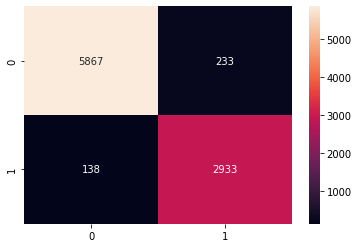

In [64]:
evaluate_model(y_test, rcf_predictions, rcf_probabilities)

/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:1692: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['int', 'str']. An error will be raised in 1.2.
  FutureWarning,
/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:1692: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['int', 'str']. An error will be raised in 1.2.
  FutureWarning,


Accuracy: 0.7591320466688475
Precision: 0.7337310195227765
Recall: 0.44057310322370563
F1 Score: 0.550559511698881
AUC-ROC: 0.6800406499725086
Mean Absolute Error: 0.24086795333115255
Root Mean Squared Error: 0.49078300024670024


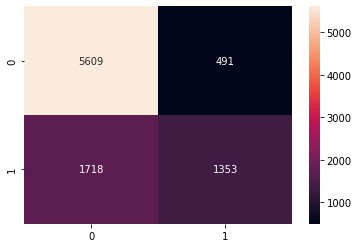

In [65]:
# Naive Bayes Classifier
# NBC performed worse than random forest on each and every aspect of the evaluation metrics

from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nbc_predictions = nb_model.predict(X_test)
nbc_probabilities = nb_model.predict_proba(X_test)[:, 1]
evaluate_model(y_test, nbc_predictions, nbc_probabilities)

/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:1692: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['int', 'str']. An error will be raised in 1.2.
  FutureWarning,
/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:1692: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['int', 'str']. An error will be raised in 1.2.
  FutureWarning,


Accuracy: 0.8332788136517283
Precision: 0.802115987460815
Recall: 0.6665581243894497
F1 Score: 0.7280810955006225
AUC-ROC: 0.791885619571774
Mean Absolute Error: 0.16672118634827174
Root Mean Squared Error: 0.4083150577045521


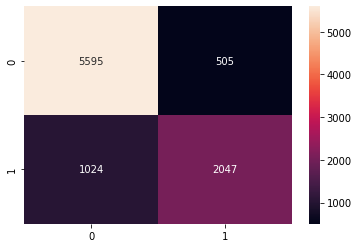

In [66]:
# KNN Classifier
# KNN was tested on different values of k

from sklearn.neighbors import KNeighborsClassifier
# model = KNeighborsClassifier(n_neighbors=8)
# model = KNeighborsClassifier(n_neighbors=5)
knn_model = KNeighborsClassifier(n_neighbors=10)
knn_model.fit(X_train, y_train)
knn_predictions = knn_model.predict(X_test)
knn_probabilities = knn_model.predict_proba(X_test)[:, 1]
evaluate_model(y_test, knn_predictions, knn_probabilities)

/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:1692: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['int', 'str']. An error will be raised in 1.2.
  FutureWarning,
/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:818: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG,
/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:1692: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['int', 'str']. An error will be raised in 1.2.
  FutureWarn

Accuracy: 0.7543343146876023
Precision: 0.7598475222363406
Recall: 0.3894496906545099
F1 Score: 0.5149623250807319
AUC-ROC: 0.663741238769878
Mean Absolute Error: 0.24566568531239777
Root Mean Squared Error: 0.4956467343909347


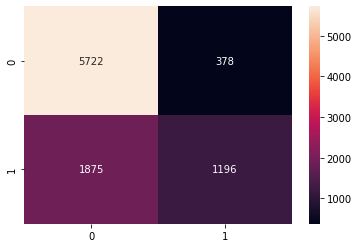

In [67]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)
lr_probabilities = lr_model.predict_proba(X_test)[:, 1]
evaluate_model(y_test, lr_predictions, lr_probabilities)

[04:51:12] WARNING: ../src/learner.cc:627: 
Parameters: { "silent" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


Accuracy: 0.8619561661759896
Precision: 0.8430254656024325
Recall: 0.7222403126017584
F1 Score: 0.7779726411785338
AUC-ROC: 0.8272676972844858
Mean Absolute Error: 0.13804383382401048
Root Mean Squared Error: 0.37154250607973577


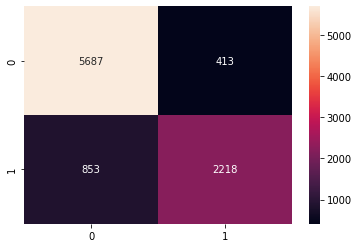

In [68]:
# XGBoost (using sklearn API for SHAP compatibility)
# XGBoost was run for different combinations of hyperparameters, but overall random forest classifier performed the best in terms of F1 score and other metrics 

import xgboost as xgb
xgb_model = xgb.XGBClassifier(
    max_depth=5, learning_rate=0.3, n_estimators=100,
    objective='binary:logistic', verbosity=0, random_state=0,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_test)
xgb_probabilities = xgb_model.predict_proba(X_test)[:, 1]
evaluate_model(y_test, xgb_predictions, xgb_probabilities)

# Testing on the data of the other hospital

In [ ]:
# testing on the other hospital data

df = get_data_ready(df_test)
X = df.drop('SepsisLabel', axis=1)
y = df['SepsisLabel']
rcf_predictions = rf_model.predict(X)
rcf_probabilities = rf_model.predict_proba(X)[:, 1]
evaluate_model(y, rcf_predictions, rcf_probabilities)

# SHAP Feature Importance Analysis

SHAP (SHapley Additive exPlanations) provides per-feature importance values for each prediction, helping us understand which clinical features drive the model's sepsis predictions.

In [ ]:
# SHAP analysis for Random Forest
sample_size = min(1000, len(X_test))
X_shap = X_test.sample(n=sample_size, random_state=42)

rf_explainer = shap.TreeExplainer(rf_model)
rf_shap_values = rf_explainer.shap_values(X_shap, check_additivity=False)

# Binary classification returns shape (n_samples, n_features, 2) — take class 1
if isinstance(rf_shap_values, list):
    rf_shap_vals = rf_shap_values[1]
else:
    rf_shap_vals = rf_shap_values
if rf_shap_vals.ndim == 3:
    rf_shap_vals = rf_shap_vals[:, :, 1]

# SHAP Summary Plot
shap.summary_plot(rf_shap_vals, X_shap, max_display=15)
plt.title("SHAP Feature Importance — Random Forest")
plt.tight_layout()
plt.show()

In [ ]:
# SHAP Bar Plot - Random Forest (mean absolute SHAP values)
shap.summary_plot(rf_shap_vals, X_shap, plot_type="bar", max_display=15)
plt.title("Mean |SHAP| Feature Importance — Random Forest")
plt.tight_layout()
plt.show()

In [ ]:
# SHAP analysis for XGBoost
xgb_explainer = shap.TreeExplainer(xgb_model)
xgb_shap_values = xgb_explainer.shap_values(X_shap)

# SHAP Summary Plot
shap.summary_plot(xgb_shap_values, X_shap, max_display=15)
plt.title("SHAP Feature Importance — XGBoost")
plt.tight_layout()
plt.show()

In [ ]:
# SHAP Bar Plot - XGBoost
shap.summary_plot(xgb_shap_values, X_shap, plot_type="bar", max_display=15)
plt.title("Mean |SHAP| Feature Importance — XGBoost")
plt.tight_layout()
plt.show()

## SHAP Interpretation

Both Random Forest and XGBoost identify **ICULOS** (ICU length of stay) and **Temp** (temperature) as the most impactful features for sepsis prediction. This makes clinical sense: longer ICU stays correlate with deterioration, and fever is a hallmark of infection.

Key lab values like **BUN**, **WBC**, and **Creatinine** also rank highly, reflecting kidney function and immune response — both critical sepsis indicators. The SHAP beeswarm plots show that high values of Temp and WBC push predictions toward sepsis (class 1), aligning with clinical expectations.

In this notebook several models were built to predict the onset of sepsis 6 hours before. After deep analysis several features were dropped and the remaining were imputed. Then the remaining features were applied with gaussian transformation and then normalized, so that a sngle feature won't start dominating the output. After all this exploration and feature engineering, several classifier models were run, in which Random Forest Classifier gave the best results.